In [1]:
!pip install kagglehub tensorflow opencv-python numpy matplotlib streamlit scikit-learn pillow

  Using cached kagglehub-0.3.12-py3-none-any.whl.metadata (38 kB)
   ---------------------------------------- 0.0/376.0 MB ? eta -:--:--
    --------------------------------------- 6.8/376.0 MB 38.1 MB/s eta 0:00:10
   - -------------------------------------- 14.4/376.0 MB 36.3 MB/s eta 0:00:10
   -- ------------------------------------- 27.3/376.0 MB 44.3 MB/s eta 0:00:08
   ---- ----------------------------------- 39.6/376.0 MB 48.4 MB/s eta 0:00:07
   ----- ---------------------------------- 50.9/376.0 MB 49.1 MB/s eta 0:00:07
   ------ --------------------------------- 63.2/376.0 MB 51.0 MB/s eta 0:00:07
   ------- -------------------------------- 74.2/376.0 MB 50.3 MB/s eta 0:00:06
   -------- ------------------------------- 81.0/376.0 MB 47.9 MB/s eta 0:00:07
   --------- ------------------------------ 92.0/376.0 MB 48.1 MB/s eta 0:00:06
   ---------- ---------------------------- 103.3/376.0 MB 49.2 MB/s eta 0:00:06
   ----------- --------------------------- 115.1/376.0 MB 49.3 M

In [3]:
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [4]:
# Téléchargement du dataset
path = kagglehub.dataset_download("hemantsoni042/celebrity-images-for-face-recognition")
print("Path to dataset files:", path)

100%|██████████| 1.71G/1.71G [00:46<00:00, 39.6MB/s]


Extracting files...
Path to dataset files: C:\Users\aough\.cache\kagglehub\datasets\hemantsoni042\celebrity-images-for-face-recognition\versions\1


In [25]:
# Vérification du contenu du dataset
# dataset_path = path
print("Contenu du dossier dataset:")
os.listdir('celebrities_images')

Contenu du dossier dataset:


['Aamir Khan',
 'Abhay Deol',
 'Abhishek Bachchan',
 'Aishwarya Rai',
 'Ajay Devgn',
 'Akshay Kumar',
 'Akshaya Khanna',
 'Akshaye Khanna',
 'Alia Bhatt',
 'Amitabh Bachchan',
 'Amy Jackson',
 'Angelina Jolie',
 'Anil Kapoor',
 'Anushka Sharma',
 'Arjun Kapoor',
 'Arjun Rampal',
 'Arshad Warsi',
 'Ayushmann Khurrana',
 'Benedict Cumberbatch',
 'Bhumi Padnekar',
 'Bipashu Basu',
 'Bobby Deol',
 'Brad Pitt',
 'Brie Larson',
 'Chris Evans',
 'Chris Hemsworth',
 'Deepika Padukone',
 'Denzel Washington',
 'Disha Patani',
 'Elizabeth Olsen',
 'Emraan Hashmi',
 'Hrithik Roshan',
 'Hugh Jackman',
 'IIeana DCruz',
 'Irrfan Khan',
 'Jacqualine Fernandez',
 'Jennifer Lawrence',
 'John Abraham',
 'Johnny Depp',
 'Josh Brolin',
 'Juhi Chawla',
 'Kangana Ranaut',
 'Kareena Kapoor',
 'Karen Gillan',
 'Karisma Kapoor',
 'Kartik Aaryan',
 'Kate Winslet',
 'Katrina Kaif',
 'Kiara Advani',
 'Kriti Sanon',
 'Leonardo DiCaprio',
 'Madhuri Dixit',
 'Manoj Bajpayee',
 'Mark Ruffalo',
 'Megan Fox',
 'Mrunal T

Exploration du dataset...
Chemin du dossier principal: celebrities_images/celebrities_images_2

Nombre de célébrités trouvées: 2

Célébrité sélectionnée aléatoirement: Amy Jackson
Nombre d'images disponibles pour Amy Jackson: 163

Image sélectionnée aléatoirement: 34.jpg


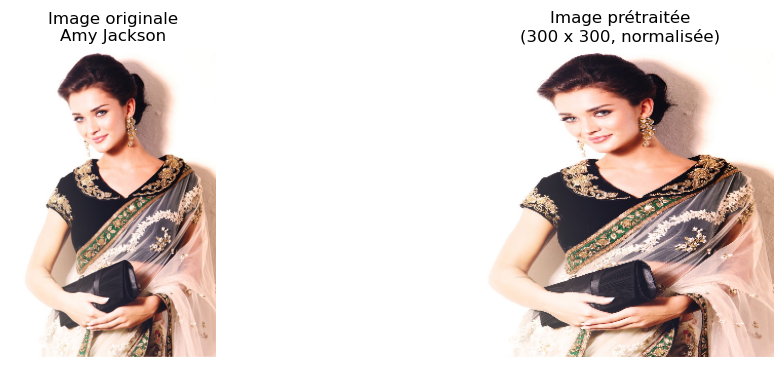


Informations sur l'image prétraitée:
Taille: (300, 300, 3)
Valeurs min/max après normalisation: 0.000, 1.000

Statistiques sur quelques célébrités (échantillon aléatoire):
Amy Jackson: 163 images
Angelina Jolie: 189 images

Nombre total de célébrités dans le dataset: 2


In [83]:
# Bloc 5 - Exploration et prétraitement des images avec sélection aléatoire
import random

def preprocess_image(image_path, target_size=(300, 300)):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Impossible de charger l'image à partir du chemin: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = img / 255.0  # Normalisation
    return img

# Exploration du dataset
print("Exploration du dataset...")
dataset_path = 'celebrities_images/celebrities_images_2'

# Chemin vers le dossier celebrities_images
celebs_path = os.path.join(dataset_path)
print(f"Chemin du dossier principal: {celebs_path}")

# Liste des dossiers de célébrités
celeb_folders = [f for f in os.listdir(celebs_path) if os.path.isdir(os.path.join(celebs_path, f))]
print(f"\nNombre de célébrités trouvées: {len(celeb_folders)}")

if celeb_folders:
    # Sélection aléatoire d'une célébrité
    random_celeb = random.choice(celeb_folders)
    celeb_path = os.path.join(celebs_path, random_celeb)
    print(f"\nCélébrité sélectionnée aléatoirement: {random_celeb}")

    # Liste des images dans ce dossier
    image_files = [f for f in os.listdir(celeb_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Nombre d'images disponibles pour {random_celeb}: {len(image_files)}")

    if image_files:
        # Sélection aléatoire d'une image
        random_image = random.choice(image_files)
        test_image_path = os.path.join(celeb_path, random_image)
        print(f"\nImage sélectionnée aléatoirement: {random_image}")

        try:
            # Prétraitement de l'image
            test_image = preprocess_image(test_image_path)

            # Affichage des images
            plt.figure(figsize=(12, 4))

            # Image originale
            plt.subplot(1, 2, 1)
            img_orig = cv2.imread(test_image_path)
            img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
            plt.imshow(img_orig)
            plt.title(f"Image originale\n{random_celeb}")
            plt.axis('off')

            # Image prétraitée
            plt.subplot(1, 2, 2)
            plt.imshow(test_image)
            plt.title(f"Image prétraitée\n(300 x 300, normalisée)")
            plt.axis('off')

            plt.show()

            print(f"\nInformations sur l'image prétraitée:")
            print(f"Taille: {test_image.shape}")
            print(f"Valeurs min/max après normalisation: {test_image.min():.3f}, {test_image.max():.3f}")

        except Exception as e:
            print(f"Erreur lors du prétraitement: {str(e)}")
    else:
        print("Aucune image trouvée dans le dossier de la célébrité")
else:
    print("Aucun dossier de célébrité trouvé")

# Afficher des statistiques aléatoires
print("\nStatistiques sur quelques célébrités (échantillon aléatoire):")
# Sélectionner 5 célébrités aléatoires pour les statistiques
sample_celebs = random.sample(celeb_folders, min(5, len(celeb_folders)))
total_images = 0

for celeb in sample_celebs:
    celeb_path = os.path.join(celebs_path, celeb)
    num_images = len([f for f in os.listdir(celeb_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{celeb}: {num_images} images")
    total_images += num_images

print(f"\nNombre total de célébrités dans le dataset: {len(celeb_folders)}")

In [26]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout

# Configuration globale
BATCH_SIZE = 16
IMAGE_SIZE = 224  # EfficientNetB3 préfère 300x300
EPOCHS = 15
LEARNING_RATE = 5e-4

def preprocess_image(image_path):
    """Prétraitement des images avec vérification et gestion d'erreurs améliorée"""
    try:
        # Chargement et vérification de l'image
        img = cv2.imread(image_path)
        if img is None:
            raise Exception(f"Impossible de charger l'image: {image_path}")
        
        # Conversion et redimensionnement
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
        
        # Prétraitement spécifique pour EfficientNet
        img = tf.keras.applications.efficientnet.preprocess_input(img)
        
        return img
    except Exception as e:
        print(f"Erreur lors du traitement de {image_path}: {str(e)}")
        return None

def load_dataset(celebs_path):
    """Chargement du dataset avec validation améliorée"""
    images = []
    labels = []
    label_dict = {}
    current_label = 0

    if not os.path.exists(celebs_path):
        raise Exception(f"Le dossier {celebs_path} n'existe pas!")

    # Parcourir chaque dossier de célébrité
    for celeb_folder in os.listdir(celebs_path):
        celeb_path = os.path.join(celebs_path, celeb_folder)
        if os.path.isdir(celeb_path):
            print(f"Chargement des images de {celeb_folder}...")
            label_dict[current_label] = celeb_folder

            # Parcourir les images
            image_files = [f for f in os.listdir(celeb_path)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

            if not image_files:
                print(f"Attention: Aucune image trouvée pour {celeb_folder}")
                continue

            valid_images = 0
            for image_file in image_files:
                image_path = os.path.join(celeb_path, image_file)
                img = preprocess_image(image_path)
                if img is not None:
                    images.append(img)
                    labels.append(current_label)
                    valid_images += 1

            print(f"Chargé {valid_images} images valides pour {celeb_folder}")
            if valid_images > 0:
                current_label += 1
            else:
                print(f"Attention: Aucune image valide pour {celeb_folder}")

    if not images:
        raise Exception("Aucune image n'a été chargée!")

    return np.array(images), np.array(labels), label_dict

def create_model(num_classes):
    """Création du modèle avec architecture améliorée"""
    # Modèle de base
    base_model = EfficientNetB3(
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

    # Fine-tuning
    base_model.trainable = True
    for layer in base_model.layers[:-100]:  # On débloque plus de couches
        layer.trainable = False

    def residual_block(x, units, dropout_rate=0.3):
        """Bloc résiduel personnalisé"""
        residual = x
        x = Dense(units, activation=None, kernel_regularizer=l2(0.0001))(x)
        x = BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = Dropout(dropout_rate)(x)
        
        # Projection résiduelle si nécessaire
        if residual.shape[-1] != units:
            residual = Dense(units, kernel_regularizer=l2(0.0001))(residual)
        
        return layers.Add()([x, residual])

    # Construction du modèle
    inputs = base_model.input
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    
    # Blocs résiduels
    x = Dense(2048, activation='relu', kernel_regularizer=l2(0.0001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    
    x = residual_block(x, 1536)
    x = residual_block(x, 1024)
    x = residual_block(x, 512)

    # Couche de sortie
    outputs = Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

def create_data_generators(X_train, y_train, X_val, y_val):
    """Création des générateurs de données avec augmentation améliorée"""
    train_datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        zoom_range=0.15,
        fill_mode='nearest',
        brightness_range=[0.8, 1.2],
        shear_range=0.15,
        channel_shift_range=0.1
    )

    val_datagen = ImageDataGenerator()

    train_generator = train_datagen.flow(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_generator = val_datagen.flow(
        X_val, y_val,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    return train_generator, val_generator

def create_callbacks():
    """Création des callbacks avec paramètres optimisés"""
    return [
        EarlyStopping(
            monitor='val_accuracy',
            patience=12,
            restore_best_weights=True,
            min_delta=0.005
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.3,
            patience=5,
            min_lr=1e-7,
            min_delta=0.005
        )
    ]

def train_model(model, train_generator, val_generator, steps_per_epoch, validation_steps):
    """Entraînement du modèle avec configuration optimisée"""
    # Learning rate schedule avec warmup
    initial_learning_rate = LEARNING_RATE
    warmup_epochs = 5
    
    def lr_schedule(epoch):
        if epoch < warmup_epochs:
            return initial_learning_rate * ((epoch + 1) / warmup_epochs)
        else:
            return initial_learning_rate * (0.95 ** (epoch - warmup_epochs))

    # Compilation
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=initial_learning_rate,
            beta_1=0.9,
            beta_2=0.999,
            epsilon=1e-08
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Entraînement
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=val_generator,
        callbacks=create_callbacks() + [
            tf.keras.callbacks.LearningRateScheduler(lr_schedule)
        ],
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        # workers=4,
        # use_multiprocessing=True
    )

    return history

def evaluate_model(model, X_val, y_val):
    """Évaluation du modèle"""
    print("\nÉvaluation finale du modèle...")
    test_loss, test_accuracy = model.evaluate(
        X_val, y_val,
        batch_size=BATCH_SIZE,
        verbose=1
    )
    print(f"Précision finale sur l'ensemble de validation: {test_accuracy*100:.2f}%")
    return test_loss, test_accuracy

def plot_training_history(history):
    """Visualisation de l'historique d'entraînement"""
    plt.figure(figsize=(15, 5))

    # Graphique de la précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entraînement')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title('Évolution de la précision')
    plt.xlabel('Époque')
    plt.ylabel('Précision')
    plt.legend()
    plt.grid(True)

    # Graphique de la perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entraînement')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title('Évolution de la perte')
    plt.xlabel('Époque')
    plt.ylabel('Perte')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def main():
    """Fonction principale"""
    # Configuration
    dataset_path = 'celebrities_images/celebrities_images_2'
    
    print("Configuration GPU...")
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print("GPU configuré avec succès")
        except RuntimeError as e:
            print(f"Erreur lors de la configuration GPU: {e}")
    else:
        print("Aucun GPU détecté, utilisation du CPU")

    try:
        # Chargement du dataset
        print("\nChargement du dataset...")
        X, y, label_dict = load_dataset(dataset_path)

        print(f"\nStatistiques du dataset:")
        print(f"Nombre total d'images: {len(X)}")
        print(f"Nombre de classes (célébrités): {len(label_dict)}")
        print(f"Forme des données: {X.shape}")

        # Division des données
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, 
            test_size=0.2, 
            random_state=42,
            stratify=y
        )

        # Création des générateurs
        train_generator, val_generator = create_data_generators(X_train, y_train, X_val, y_val)

        # Création et entraînement du modèle
        print("\nCréation du modèle...")
        model = create_model(len(label_dict))
        # model.summary()

        print("\nDébut de l'entraînement...")
        steps_per_epoch = len(X_train) // BATCH_SIZE
        validation_steps = len(X_val) // BATCH_SIZE

        history = train_model(
            model,
            train_generator,
            val_generator,
            steps_per_epoch,
            validation_steps
        )

        # Évaluation et visualisation
        evaluate_model(model, X_val, y_val)
        plot_training_history(history)

        # Sauvegarde du modèle et des labels
        print("\nSauvegarde du modèle et des labels...")
        model.save('face_recognition_model_with_EfficientNetB3.h5')
        import pickle
        with open('label_dict.pkl', 'wb') as f:
            pickle.dump(label_dict, f)
        print("Sauvegarde terminée!") 

    except Exception as e:
        print(f"\nErreur lors de l'exécution: {str(e)}")

if __name__ == "__main__":
    main()


Aucun GPU détecté, utilisation du CPU

Chargement du dataset...
Chargement des images de 'Aamir Khan'...
Chargement des images de 'Abhay Deol'...
Chargement des images de 'Abhishek Bachchan'...
Chargement des images de 'Aishwarya Rai'...
Chargement des images de 'Ajay Devgn'...
Chargement des images de 'Akshay Kumar'...
Chargement des images de 'Akshaya Khanna'...
Chargement des images de 'Akshaye Khanna'...
Chargement des images de 'Alia Bhatt'...
Chargement des images de 'Amitabh Bachchan'...
Chargement des images de 'Amy Jackson'...
Chargement des images de 'Angelina Jolie'...
Chargement des images de 'Anil Kapoor'...
Chargement des images de 'Anushka Sharma'...
Chargement des images de 'Arjun Kapoor'...
Chargement des images de 'Arjun Rampal'...
Chargement des images de 'Arshad Warsi'...
Chargement des images de 'Ayushmann Khurrana'...
Chargement des images de 'Benedict Cumberbatch'...
Chargement des images de 'Bhumi Padnekar'...
Chargement des images de 'Bipashu Basu'...
Chargemen

c:\Users\aough\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
158/610 ━━━━━━━━━━━━━━━━━━━━ 9:55 1s/step - accuracy: 0.0134 - loss: 6.3805

KeyboardInterrupt: 

Aucun GPU détecté, utilisation du CPU

Chargement du dataset...
Chargement des images de 'Amy Jackson'...
Chargement des images de 'Angelina Jolie'...
Chargement des images de 'Hugh Jackman'...
Données chargées : 300 images | 3 classes

Création du modèle avec MobileNetV2...


c:\Users\aough\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.3703 - loss: 1.3248

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 587ms/step - accuracy: 0.3751 - loss: 1.3208 - val_accuracy: 0.5000 - val_loss: 1.0224 - learning_rate: 1.0000e-04
Epoch 2/20
1/7 ━━━━━━━━━━━━━━━━━━━━ 1s 306ms/step - accuracy: 0.4375 - loss: 1.1549

c:\Users\aough\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 769ms/step - accuracy: 0.7268 - loss: 0.6281 - val_accuracy: 0.7500 - val_loss: 0.5299 - learning_rate: 1.0000e-04
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.7500 - loss: 0.5934 - val_accuracy: 0.7188 - val_loss: 0.5252 - learning_rate: 1.0000e-04
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 667ms/step - accuracy: 0.7291 - loss: 0.5786 - val_accuracy: 0.7500 - val_loss: 0.4784 - learning_rate: 1.0000e-04
Epoch 10/20
1/7 ━━━━━━━━━━━━━━━━━━━━ 3s 510ms/step - accuracy: 0.7812 - loss: 0.4759

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - accuracy: 0.7812 - loss: 0.4759 - val_accuracy: 0.8125 - val_loss: 0.4754 - learning_rate: 1.0000e-04
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 709ms/step - accuracy: 0.7890 - loss: 0.4508 - val_accuracy: 0.8125 - val_loss: 0.4719 - learning_rate: 1.0000e-04
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.8125 - loss: 0.4402 - val_accuracy: 0.8125 - val_loss: 0.4693 - learning_rate: 1.0000e-04
Epoch 13/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 608ms/step - accuracy: 0.8062 - loss: 0.4550 - val_accuracy: 0.8125 - val_loss: 0.4511 - learning_rate: 1.0000e-04
Epoch 14/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.8438 - loss: 0.3747 - val_accuracy: 0.8125 - val_loss: 0.4478 - learning_rate: 1.0000e-04
Epoch 15/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 597ms/step - accuracy: 0.8445 - loss: 0.4066 - val_accuracy: 0.7500 - val_loss: 0.4280 - learning_rate: 1.0000e-04
Epoch 16/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 0.8438 - loss: 0.439

7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.5746 - loss: 0.9013 - val_accuracy: 0.7812 - val_loss: 0.4896 - learning_rate: 1.0000e-05
Epoch 2/10
1/7 ━━━━━━━━━━━━━━━━━━━━ 4s 798ms/step - accuracy: 0.6875 - loss: 0.8498

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.6875 - loss: 0.8498 - val_accuracy: 0.8125 - val_loss: 0.4930 - learning_rate: 1.0000e-05
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6043 - loss: 0.8303 - val_accuracy: 0.7812 - val_loss: 0.5151 - learning_rate: 1.0000e-05
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.7500 - loss: 0.7108 - val_accuracy: 0.7500 - val_loss: 0.5187 - learning_rate: 1.0000e-05
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7248 - loss: 0.6938 - val_accuracy: 0.7500 - val_loss: 0.5441 - learning_rate: 1.0000e-05
Epoch 6/10
1/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5938 - loss: 0.8073
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.5938 - loss: 0.8073 - val_accuracy: 0.7500 - val_loss: 0.5466 - learning_rate: 1.0000e-05
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7196 - loss: 0.6499 - val_accuracy: 

Modèle et dictionnaire sauvegardés.


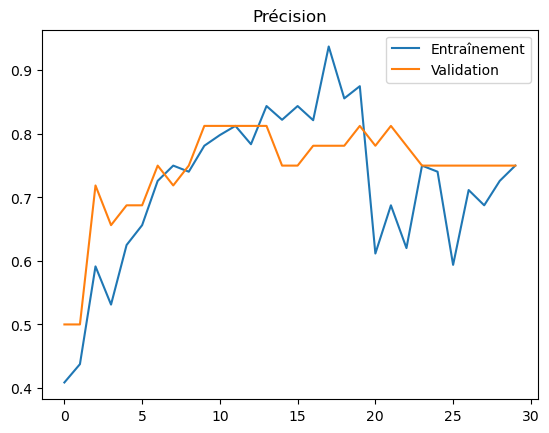

In [39]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pickle

# -------------------------------
# Configuration globale
# -------------------------------
BATCH_SIZE = 32
IMAGE_SIZE = 224  # Taille d'entrée pour MobileNetV2
EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_CLASSES = 3  # Nombre de classes (peut être augmenté à 98)

# -------------------------------
# Chargement du dataset
# -------------------------------
def load_dataset(celebs_path, max_classes=3):
    images = []
    labels = []
    label_dict = {}

    if not os.path.exists(celebs_path):
        raise FileNotFoundError(f"Le dossier {celebs_path} n'existe pas!")

    class_count = 0
    for celeb_folder in os.listdir(celebs_path):
        celeb_path = os.path.join(celebs_path, celeb_folder)

        if os.path.isdir(celeb_path):
            print(f"Chargement des images de '{celeb_folder}'...")
            
            if class_count >= max_classes:
                break
            
            label_dict[class_count] = celeb_folder
            image_files = [f for f in os.listdir(celeb_path)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:100]

            for img_file in image_files:
                img_path = os.path.join(celeb_path, img_file)
                try:
                    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
                    img = tf.keras.preprocessing.image.img_to_array(img)
                    img = img / 255.0  # Normalisation
                    images.append(img)
                    labels.append(class_count)
                except Exception as e:
                    print(f"Erreur lors du traitement de {img_path}: {str(e)}")

            class_count += 1

    if not images:
        raise ValueError("Aucune image valide trouvée !")

    return np.array(images), np.array(labels), label_dict

# -------------------------------
# Création du modèle avec MobileNetV2
# -------------------------------
def create_transfer_learning_model(num_classes):
    # Charger MobileNetV2 pré-entraîné (sans les couches fully connected)
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    base_model.trainable = False  # Geler les poids du modèle de base

    # Ajouter des couches personnalisées pour fine-tuning
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# -------------------------------
# Data augmentation
# -------------------------------
def create_augmented_generators(X_train, y_train, X_val, y_val):
    train_datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    val_datagen = ImageDataGenerator()  # Pas d'augmentation pour la validation

    train_generator = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
    val_generator = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

    return train_generator, val_generator

# -------------------------------
# Callbacks optimisés
# -------------------------------
def setup_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy'),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=5, verbose=1, min_lr=1e-6),
        tf.keras.callbacks.ModelCheckpoint('best_face_recognition_model.h5', save_best_only=True, monitor='val_accuracy')
    ]

# -------------------------------
# Fonction principale
# -------------------------------
def main():
    dataset_path = 'celebrities_images_2'

    # -- Configuration GPU --
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print("GPU configuré.")
        except RuntimeError as e:
            print(e)
    else:
        print("Aucun GPU détecté, utilisation du CPU")

    # -- Chargement du dataset --
    print("\nChargement du dataset...")
    X, y, label_dict = load_dataset(dataset_path, max_classes=3)
    print(f"Données chargées : {X.shape[0]} images | {len(label_dict)} classes")

    # -- Division entraînement/validation --
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # -- Générateurs avec augmentation --
    train_gen, val_gen = create_augmented_generators(X_train, y_train, X_val, y_val)

    # -- Création du modèle --
    print("\nCréation du modèle avec MobileNetV2...")
    model = create_transfer_learning_model(len(label_dict))

    # -- Compilation --
    optimizer = Adam(learning_rate=LEARNING_RATE)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # -- Entraînement --
    history = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=val_gen,
        steps_per_epoch=len(X_train) // BATCH_SIZE,
        validation_steps=len(X_val) // BATCH_SIZE,
        callbacks=setup_callbacks()
    )

    # -- Évaluation finale --
    print("\nÉvaluation finale du modèle...")
    loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"Perte : {loss:.4f}, Précision : {accuracy * 100:.2f}%")

    # -- Fine-tuning --
    print("\nDébut du fine-tuning...")
    base_model = model.layers[0]
    base_model.trainable = True  # Débloquer les poids de MobileNetV2 pour le fine-tuning

    # Recompiler avec un learning rate plus faible
    optimizer_finetune = Adam(learning_rate=LEARNING_RATE / 10)
    model.compile(optimizer=optimizer_finetune, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Entraîner à nouveau
    history_finetune = model.fit(
        train_gen,
        epochs=EPOCHS // 2,  # Moins d'époques pour le fine-tuning
        validation_data=val_gen,
        steps_per_epoch=len(X_train) // BATCH_SIZE,
        validation_steps=len(X_val) // BATCH_SIZE,
        callbacks=setup_callbacks()
    )

    # -- Sauvegarde --
    model.save('face_recognition_model_transfer_learning.h5')
    with open('label_dict.pkl', 'wb') as f:
        pickle.dump(label_dict, f)
    print("Modèle et dictionnaire sauvegardés.")

    # -- Graphiques --
    plt.plot(history.history['accuracy'] + history_finetune.history['accuracy'], label='Entraînement')
    plt.plot(history.history['val_accuracy'] + history_finetune.history['val_accuracy'], label='Validation')
    plt.title('Précision')
    plt.legend()
    plt.savefig('training_accuracy.png')
    plt.show()

if __name__ == "__main__":
    main()

Aucun GPU détecté, utilisation du CPU

Chargement du dataset...
Chargement des images de 'celebrities_images_2'...
Images valides trouvées dans 'celebrities_images_2': []
Chargement des images de 'Amy Jackson'...
Images valides trouvées dans 'Amy Jackson': ['celebrities_images_2\\Amy Jackson\\1.jpg', 'celebrities_images_2\\Amy Jackson\\10.jpg', 'celebrities_images_2\\Amy Jackson\\100.jpg', 'celebrities_images_2\\Amy Jackson\\101.jpg', 'celebrities_images_2\\Amy Jackson\\102.jpg', 'celebrities_images_2\\Amy Jackson\\103.jpg', 'celebrities_images_2\\Amy Jackson\\104.jpg', 'celebrities_images_2\\Amy Jackson\\105.jpg', 'celebrities_images_2\\Amy Jackson\\106.jpg', 'celebrities_images_2\\Amy Jackson\\107.jpg', 'celebrities_images_2\\Amy Jackson\\108.jpg', 'celebrities_images_2\\Amy Jackson\\109.jpg', 'celebrities_images_2\\Amy Jackson\\11.jpg', 'celebrities_images_2\\Amy Jackson\\110.jpg', 'celebrities_images_2\\Amy Jackson\\111.jpg', 'celebrities_images_2\\Amy Jackson\\112.jpg', 'celebriti

ValueError: Aucune image valide trouvée !